<a href="https://colab.research.google.com/github/ADRAKECROWDER/AIML2013-cv/blob/main/Week5/DemographicBiasAudit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Setup

# Install missing packages for dataset loading
!pip install -q tensorflow_datasets datasets

# Import core libraries
import os
import random
import warnings
warnings.filterwarnings("ignore")

# Import data and model tools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds

# Import Hugging Face dataset loader
from datasets import load_dataset

# Import sklearn metrics and model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.linear_model import LogisticRegression

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Print environment confirmation
print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Cell 2

Loads the CelebA image data, prepares the images and labels, extracts MobileNetV2 features, and trains the classifier head for smiling.

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Class balance for TARGET_ATTR = Smiling
0 (Not Smiling): 477
1 (Smiling): 523


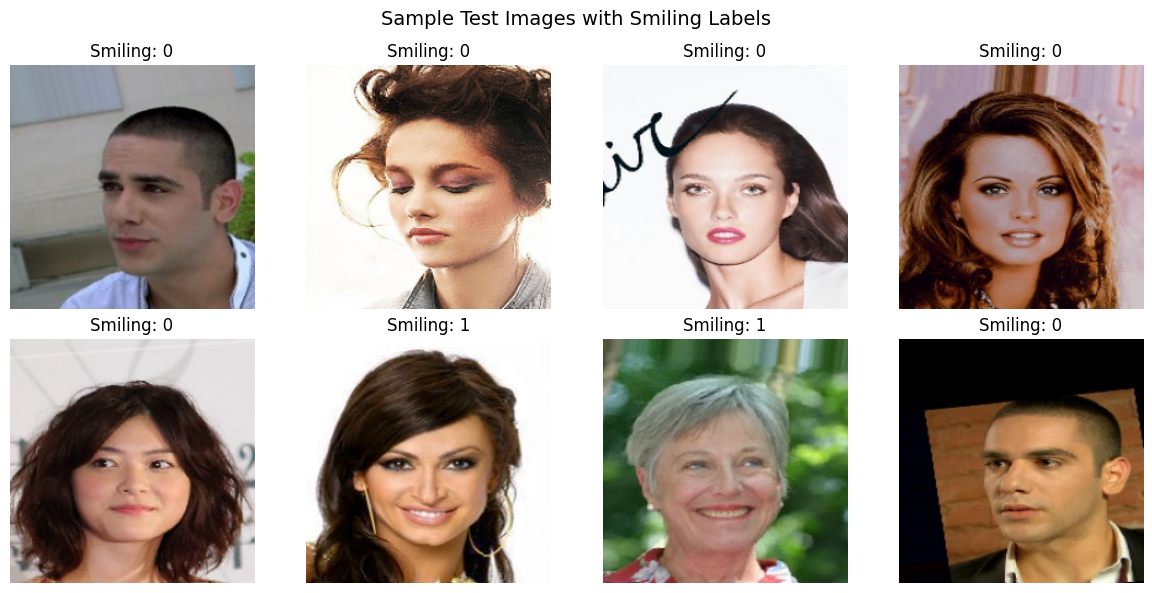

In [2]:
# Cell 2: Load Dataset and Classifier

# Suppress Hugging Face download warnings and progress output
import os
import logging
from contextlib import redirect_stdout, redirect_stderr
from huggingface_hub.utils import disable_progress_bars
from datasets.utils.logging import disable_progress_bar, set_verbosity_error

# Turn off Hugging Face progress bars and warnings
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"
os.environ["DATASETS_VERBOSITY"] = "error"
disable_progress_bars()
disable_progress_bar()
set_verbosity_error()
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("datasets").setLevel(logging.ERROR)

# Set the target attribute for prediction
TARGET_ATTR = "Smiling"

# Define subgroup attributes used later for slicing
required_attrs = ["Male", "Young", "Wearing_Hat", "Smiling", "Eyeglasses"]

# Load train and test splits from Hugging Face without printing metadata
with open(os.devnull, "w") as f, redirect_stdout(f), redirect_stderr(f):
    train_ds = load_dataset("flwrlabs/celebA", split="train[:2000]")
    test_ds = load_dataset("flwrlabs/celebA", split="test[:1000]")

# Build a robust attribute reader for different dataset schemas
def get_attr_value(example, attr_name):
    # Read from nested attributes dictionary if present
    if "attributes" in example and isinstance(example["attributes"], dict):
        value = example["attributes"].get(attr_name, 0)
    # Read from nested attr dictionary if present
    elif "attr" in example and isinstance(example["attr"], dict):
        value = example["attr"].get(attr_name, 0)
    # Read from top-level column if present
    elif attr_name in example:
        value = example[attr_name]
    else:
        value = 0

    # Convert values to clean booleans
    if isinstance(value, (np.bool_, bool)):
        return bool(value)
    if isinstance(value, str):
        return value.lower() in ["1", "true", "yes"]
    return int(value) > 0

# Resize each image to MobileNetV2 input size
def prepare_image(img):
    # Convert the image to a float32 array
    img = np.array(img).astype("float32")
    # Resize the image to 224x224 pixels
    img = tf.image.resize(img, (224, 224)).numpy()
    return img

# Convert dataset split into image arrays and labels
def process_split(ds, attr_names, target_attr):
    # Store resized raw images for later display
    raw_images = []
    # Store selected labels for DataFrame creation
    label_rows = []

    for ex in ds:
        # Resize and save the image
        raw_images.append(prepare_image(ex["image"]))

        # Collect selected boolean attributes
        row = {attr: get_attr_value(ex, attr) for attr in attr_names}
        label_rows.append(row)

    # Stack images into one array
    raw_images = np.stack(raw_images).astype("float32")
    # Convert labels into a DataFrame
    labels = pd.DataFrame(label_rows)
    # Convert target labels into 0/1 integers
    y = labels[target_attr].astype(int).to_numpy()

    return raw_images, labels, y

# Process training and test splits
train_images_raw, train_labels_df, y_train = process_split(train_ds, required_attrs, TARGET_ATTR)
test_images_raw, labels_df, y_true = process_split(test_ds, required_attrs, TARGET_ATTR)

# Preprocess images for MobileNetV2
images = tf.keras.applications.mobilenet_v2.preprocess_input(test_images_raw.copy())
train_images = tf.keras.applications.mobilenet_v2.preprocess_input(train_images_raw.copy())

# Build frozen MobileNetV2 feature extractor
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
    pooling="avg",
)

# Freeze the MobileNetV2 feature extractor
base_model.trainable = False

# Extract embeddings without printing progress bars
train_emb = base_model.predict(train_images, batch_size=32, verbose=0)
test_emb = base_model.predict(images, batch_size=32, verbose=0)

# Fit logistic regression classifier on training embeddings
clf = LogisticRegression(
    max_iter=2000,
    random_state=42,
    class_weight="balanced",
)
clf.fit(train_emb, y_train)

# Create Keras model input layer
inputs = tf.keras.Input(shape=(224, 224, 3))

# Pass images through frozen MobileNetV2
x = base_model(inputs, training=False)

# Add sigmoid classifier head
outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="logreg_head")(x)

# Combine feature extractor and classifier head into one model
model = tf.keras.Model(inputs, outputs)

# Copy logistic regression weights into the Keras Dense layer
dense_layer = model.get_layer("logreg_head")
dense_layer.set_weights([
    clf.coef_.T.astype("float32"),
    clf.intercept_.astype("float32")
])

# Print only useful class balance information
class_counts = pd.Series(y_true).value_counts().sort_index()
print(f"Class balance for TARGET_ATTR = {TARGET_ATTR}")
print(f"0 (Not {TARGET_ATTR}): {class_counts.get(0, 0)}")
print(f"1 ({TARGET_ATTR}): {class_counts.get(1, 0)}")

# Show sample test images with their target labels
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
sample_idxs = np.random.choice(len(test_images_raw), size=8, replace=False)

for ax, idx in zip(axes.ravel(), sample_idxs):
    # Display raw image for visual checking
    ax.imshow(test_images_raw[idx].astype("uint8"))
    # Show the target label above each image
    ax.set_title(f"{TARGET_ATTR}: {int(y_true[idx])}")
    ax.axis("off")

plt.suptitle(f"Sample Test Images with {TARGET_ATTR} Labels", fontsize=14)
plt.tight_layout()
plt.show()

### Cell 3:
Runs the classifier on the test images and calculates the overall performance metrics.

Overall metrics for TARGET_ATTR = Smiling
Accuracy: 0.714
Precision: 0.718
Recall: 0.746
F1: 0.732

Classification Report:
              precision    recall  f1-score   support

 Not Smiling       0.71      0.68      0.69       477
     Smiling       0.72      0.75      0.73       523

    accuracy                           0.71      1000
   macro avg       0.71      0.71      0.71      1000
weighted avg       0.71      0.71      0.71      1000



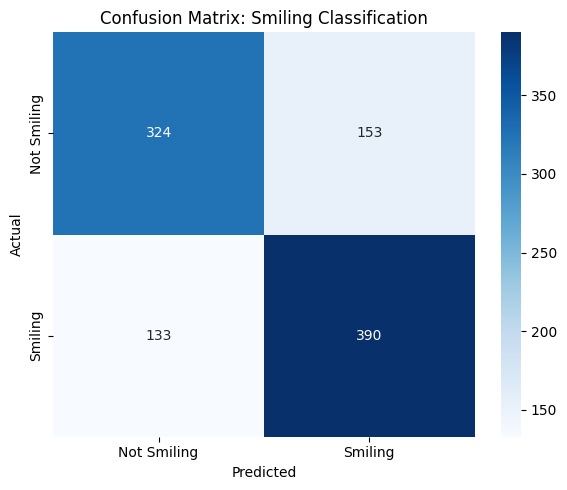

In [3]:
# Cell 3: Overall Predictions and Metrics

# Predict probabilities on the full test set
y_pred_proba = model.predict(images, batch_size=32, verbose=0).ravel()

# Convert probabilities to binary predictions at 0.5
y_pred = (y_pred_proba >= 0.5).astype(int)

# Compute overall classification metrics
overall_metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred, zero_division=0),
    "recall": recall_score(y_true, y_pred, zero_division=0),
    "f1": f1_score(y_true, y_pred, zero_division=0),
}

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Print overall metrics
print(f"Overall metrics for TARGET_ATTR = {TARGET_ATTR}")
for metric_name, metric_value in overall_metrics.items():
    print(f"{metric_name.capitalize()}: {metric_value:.3f}")

# Print detailed classification report
print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[f"Not {TARGET_ATTR}", TARGET_ATTR],
        zero_division=0,
    )
)

# Plot confusion matrix heatmap with raw counts
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[f"Not {TARGET_ATTR}", TARGET_ATTR],
    yticklabels=[f"Not {TARGET_ATTR}", TARGET_ATTR],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix: {TARGET_ATTR} Classification")
plt.tight_layout()
plt.show()

### Cell 3 Output
 shows that the Smiling classifier was about 71.4% accurate overall. It performed slightly better at finding Smiling faces than Not Smiling faces, with a recall of 0.746 for Smiling and 0.680 for Not Smiling.

### Cell 4:
Breaks the results into subgroups and compares model performance across each attribute group.

Highest accuracy group:
{'attribute': 'Smiling', 'group': True, 'accuracy': 0.745697896749522, 'precision': 1.0, 'recall': 0.745697896749522, 'f1': 0.8543263964950711, 'n_samples': 523}

Lowest accuracy group:
{'attribute': 'Wearing_Hat', 'group': True, 'accuracy': 0.6363636363636364, 'precision': 0.7142857142857143, 'recall': 0.45454545454545453, 'f1': 0.5555555555555556, 'n_samples': 22}

Accuracy gap: 0.109


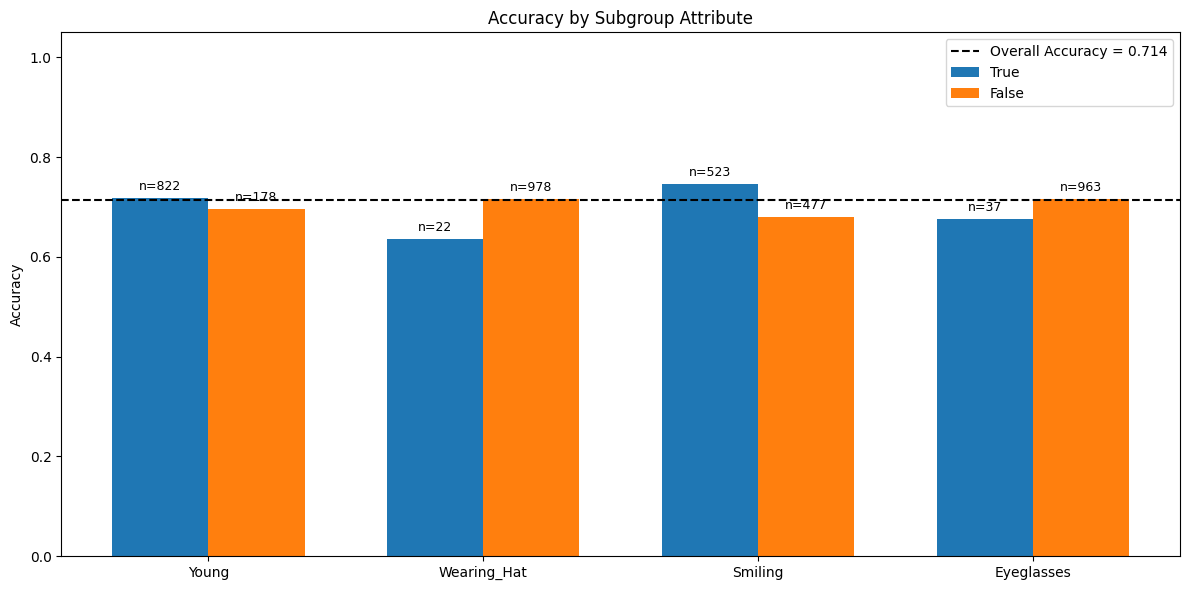

,attribute,group,accuracy,precision,recall,f1,n_samples
0,Young,True,0.717762,0.696759,0.748756,0.721823,822
1,Young,False,0.696629,0.801802,0.735537,0.767241,178
2,Wearing_Hat,True,0.636364,0.714286,0.454545,0.555556,22
3,Wearing_Hat,False,0.715746,0.718284,0.751953,0.734733,978
4,Smiling,True,0.745698,1.000000,0.745698,0.854326,523
5,Smiling,False,0.679245,0.000000,0.000000,0.000000,477
6,Eyeglasses,True,0.675676,0.875000,0.388889,0.538462,37
7,Eyeglasses,False,0.715472,0.715888,0.758416,0.736538,963


In [4]:
# Cell 4: Per-Group Accuracy by Attribute

# Define attributes used for subgroup slicing
slice_attributes = ["Young", "Wearing_Hat", "Smiling", "Eyeglasses"]

# Store subgroup metric rows
group_rows = []

for attr in slice_attributes:
    for group_value in [True, False]:
        # Build subgroup mask for current attribute value
        mask = labels_df[attr] == group_value

        # Slice labels and predictions for this subgroup
        y_true_g = y_true[mask]
        y_pred_g = y_pred[mask]
        n_samples = int(mask.sum())

        # Skip empty groups to avoid invalid metrics
        if n_samples == 0:
            continue

        # Compute subgroup metrics safely
        acc = accuracy_score(y_true_g, y_pred_g)
        prec = precision_score(y_true_g, y_pred_g, zero_division=0)
        rec = recall_score(y_true_g, y_pred_g, zero_division=0)
        f1 = f1_score(y_true_g, y_pred_g, zero_division=0)

        # Store all metrics in one row
        group_rows.append(
            {
                "attribute": attr,
                "group": group_value,
                "accuracy": acc,
                "precision": prec,
                "recall": rec,
                "f1": f1,
                "n_samples": n_samples,
            }
        )

# Build group metrics DataFrame
group_metrics = pd.DataFrame(group_rows)

# Print caution for very small subgroups
small_groups = group_metrics[group_metrics["n_samples"] < 20]
if not small_groups.empty:
    print("Caution: small sample size detected for these groups:")
    print(small_groups[["attribute", "group", "n_samples"]].to_string(index=False))

# Find highest and lowest accuracy subgroups
best_group = group_metrics.loc[group_metrics["accuracy"].idxmax()]
worst_group = group_metrics.loc[group_metrics["accuracy"].idxmin()]
gap = best_group["accuracy"] - worst_group["accuracy"]

# Print summary of subgroup extremes
print("Highest accuracy group:")
print(best_group.to_dict())
print("\nLowest accuracy group:")
print(worst_group.to_dict())
print(f"\nAccuracy gap: {gap:.3f}")

# Plot grouped bar chart of subgroup accuracies
plot_df = group_metrics.copy()
plot_df["group_label"] = plot_df["group"].map({True: "True", False: "False"})

# Set up grouped bar positions
attrs = slice_attributes
x = np.arange(len(attrs))
width = 0.35

# Collect accuracy values in attribute order
true_vals = [
    plot_df[(plot_df["attribute"] == attr) & (plot_df["group"] == True)]["accuracy"].values[0]
    for attr in attrs
]
false_vals = [
    plot_df[(plot_df["attribute"] == attr) & (plot_df["group"] == False)]["accuracy"].values[0]
    for attr in attrs
]
true_ns = [
    plot_df[(plot_df["attribute"] == attr) & (plot_df["group"] == True)]["n_samples"].values[0]
    for attr in attrs
]
false_ns = [
    plot_df[(plot_df["attribute"] == attr) & (plot_df["group"] == False)]["n_samples"].values[0]
    for attr in attrs
]

# Draw subgroup bars
fig, ax = plt.subplots(figsize=(12, 6))
bars_true = ax.bar(x - width / 2, true_vals, width, label="True")
bars_false = ax.bar(x + width / 2, false_vals, width, label="False")

# Add overall accuracy reference line
ax.axhline(
    overall_metrics["accuracy"],
    linestyle="--",
    linewidth=1.5,
    color="black",
    label=f"Overall Accuracy = {overall_metrics['accuracy']:.3f}",
)

# Add sample counts above each bar
for bar, n in zip(bars_true, true_ns):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"n={n}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

for bar, n in zip(bars_false, false_ns):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"n={n}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

# Format chart labels
ax.set_xticks(x)
ax.set_xticklabels(attrs)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by Subgroup Attribute")
ax.legend()
plt.tight_layout()
plt.show()

# Display final table for review
group_metrics

###Cell 4 Output
shows that accuracy was highest for faces labeled Smiling=True and lowest for Wearing_Hat=True. The accuracy gap was 0.109, meaning the classifier performed noticeably worse on determing smiles on people wearing hats, though that group was small with only 22 samples.

### Cell 5:
Combines two subgroup attributes to check whether performance changes when groups overlap.

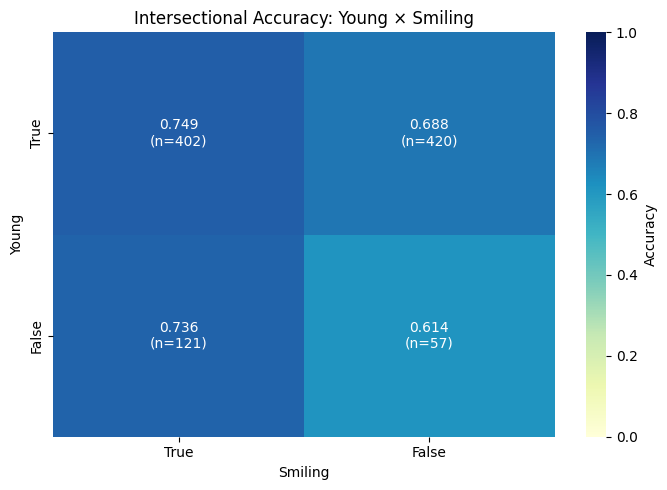

Best-performing intersection:
{'attribute_a': 'Young', 'attribute_b': 'Smiling', 'group_a': True, 'group_b': True, 'accuracy': 0.7487562189054726, 'precision': 1.0, 'recall': 0.7487562189054726, 'f1': 0.8563300142247511, 'n_samples': 402}

Worst-performing intersection:
{'attribute_a': 'Young', 'attribute_b': 'Smiling', 'group_a': False, 'group_b': False, 'accuracy': 0.6140350877192983, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'n_samples': 57}

Intersectional accuracy gap: 0.135


,attribute_a,attribute_b,group_a,group_b,accuracy,precision,recall,f1,n_samples
0,Young,Smiling,True,True,0.748756,1.0,0.748756,0.856330,402
1,Young,Smiling,True,False,0.688095,0.0,0.000000,0.000000,420
2,Young,Smiling,False,True,0.735537,1.0,0.735537,0.847619,121
3,Young,Smiling,False,False,0.614035,0.0,0.000000,0.000000,57


In [5]:
# Cell 5: Intersectional Analysis

# Choose two attributes for intersectional auditing
ATTR_A = "Young"
ATTR_B = "Smiling"

# Store intersection metric rows
intersect_rows = []

for group_a in [True, False]:
    for group_b in [True, False]:
        # Build mask for the current attribute combination
        mask = (labels_df[ATTR_A] == group_a) & (labels_df[ATTR_B] == group_b)

        # Slice labels and predictions for this intersection
        y_true_g = y_true[mask]
        y_pred_g = y_pred[mask]
        n_samples = int(mask.sum())

        # Skip empty cells to avoid invalid metrics
        if n_samples == 0:
            continue

        # Compute intersection metrics safely
        acc = accuracy_score(y_true_g, y_pred_g)
        prec = precision_score(y_true_g, y_pred_g, zero_division=0)
        rec = recall_score(y_true_g, y_pred_g, zero_division=0)
        f1 = f1_score(y_true_g, y_pred_g, zero_division=0)

        # Store metrics for this intersection
        intersect_rows.append(
            {
                "attribute_a": ATTR_A,
                "attribute_b": ATTR_B,
                "group_a": group_a,
                "group_b": group_b,
                "accuracy": acc,
                "precision": prec,
                "recall": rec,
                "f1": f1,
                "n_samples": n_samples,
            }
        )

# Build intersection metrics DataFrame
intersect_metrics = pd.DataFrame(intersect_rows)

# Warn if any intersection cell is very small
small_intersections = intersect_metrics[intersect_metrics["n_samples"] < 15]
if not small_intersections.empty:
    print("Note: some intersectional groups have fewer than 15 samples.")
    print(small_intersections[["group_a", "group_b", "n_samples"]].to_string(index=False))

# Build accuracy matrix for the 2x2 heatmap
acc_matrix = intersect_metrics.pivot(
    index="group_a",
    columns="group_b",
    values="accuracy",
).reindex(index=[True, False], columns=[True, False])

# Build sample count matrix for annotations
n_matrix = intersect_metrics.pivot(
    index="group_a",
    columns="group_b",
    values="n_samples",
).reindex(index=[True, False], columns=[True, False])

# Create annotation strings with accuracy and sample count
annot = acc_matrix.copy().astype(object)
for i in acc_matrix.index:
    for j in acc_matrix.columns:
        acc_val = acc_matrix.loc[i, j]
        n_val = n_matrix.loc[i, j]
        annot.loc[i, j] = f"{acc_val:.3f}\n(n={int(n_val)})"

# Plot intersectional accuracy heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    acc_matrix,
    annot=annot,
    fmt="",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Accuracy"},
)
plt.title(f"Intersectional Accuracy: {ATTR_A} × {ATTR_B}")
plt.xlabel(f"{ATTR_B}")
plt.ylabel(f"{ATTR_A}")
plt.tight_layout()
plt.show()

# Print best and worst intersection gap
best_intersection = intersect_metrics.loc[intersect_metrics["accuracy"].idxmax()]
worst_intersection = intersect_metrics.loc[intersect_metrics["accuracy"].idxmin()]
intersection_gap = best_intersection["accuracy"] - worst_intersection["accuracy"]

print("Best-performing intersection:")
print(best_intersection.to_dict())
print("\nWorst-performing intersection:")
print(worst_intersection.to_dict())
print(f"\nIntersectional accuracy gap: {intersection_gap:.3f}")

# Display final table for review
intersect_metrics

###Cell 5 Output
Row 1 means there were 402 samples where the person was young and actually smiling, and the model correctly predicted they were smiling about 74.9% of the time.

Row 2 means there were 420 samples where the person was young and actually not smiling, and the model correctly predicted not smiling about 68.8% of the time.

Row 3 means there were 121 samples where the person was not young and actually smiling, and the model correctly predicted smiling about 73.6% of the time.

Row 4 means there were 57 samples where the person was not young and actually not smiling, and the model correctly predicted not smiling about 61.4% of the time.

### Cell 6:
Compares the error patterns for the best-performing and worst-performing subgroups.

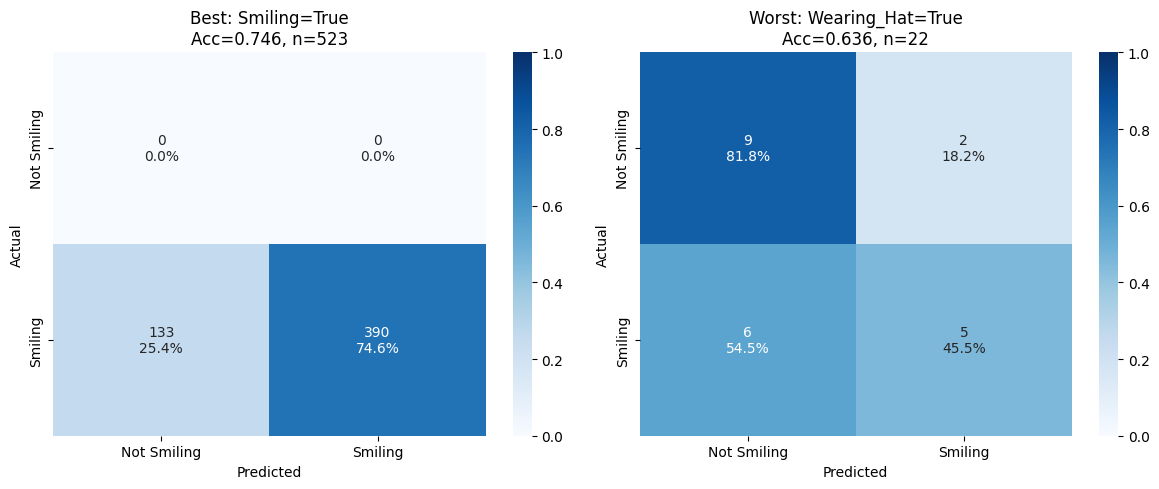

Best subgroup (Smiling=True): FNR=0.254, FPR=0.000
Worst subgroup (Wearing_Hat=True): FNR=0.545, FPR=0.182
The worst subgroup has a higher false negative rate than the best subgroup.


In [6]:
# Cell 6: Per-Group Confusion Matrices

# Re-identify best and worst subgroup from Cell 4
best_group = group_metrics.loc[group_metrics["accuracy"].idxmax()]
worst_group = group_metrics.loc[group_metrics["accuracy"].idxmin()]

# Helper to compute raw and row-normalized confusion matrices
def get_group_confusion(mask):
    # Slice true and predicted labels for this subgroup
    y_true_g = y_true[mask]
    y_pred_g = y_pred[mask]

    # Compute raw 2x2 confusion matrix
    cm_raw = confusion_matrix(y_true_g, y_pred_g, labels=[0, 1])

    # Normalize rows safely to avoid divide-by-zero
    row_sums = cm_raw.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm_raw, row_sums, out=np.zeros_like(cm_raw, dtype=float), where=row_sums != 0)

    return cm_raw, cm_norm, y_true_g, y_pred_g

# Build masks for best and worst subgroups
best_mask = labels_df[best_group["attribute"]] == best_group["group"]
worst_mask = labels_df[worst_group["attribute"]] == worst_group["group"]

# Compute confusion matrices for both groups
best_cm_raw, best_cm_norm, best_y_true, best_y_pred = get_group_confusion(best_mask)
worst_cm_raw, worst_cm_norm, worst_y_true, worst_y_pred = get_group_confusion(worst_mask)

# Build annotation labels with raw counts and percentages
def make_cm_annotations(cm_raw, cm_norm):
    # Create readable annotation text for each cell
    annotations = np.empty_like(cm_raw, dtype=object)
    for i in range(cm_raw.shape[0]):
        for j in range(cm_raw.shape[1]):
            annotations[i, j] = f"{cm_raw[i, j]}\n{cm_norm[i, j]:.1%}"
    return annotations

best_annot = make_cm_annotations(best_cm_raw, best_cm_norm)
worst_annot = make_cm_annotations(worst_cm_raw, worst_cm_norm)

# Plot side-by-side normalized confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    best_cm_norm,
    annot=best_annot,
    fmt="",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=[f"Not {TARGET_ATTR}", TARGET_ATTR],
    yticklabels=[f"Not {TARGET_ATTR}", TARGET_ATTR],
    ax=axes[0],
)
axes[0].set_title(
    f"Best: {best_group['attribute']}={best_group['group']}\n"
    f"Acc={best_group['accuracy']:.3f}, n={int(best_group['n_samples'])}"
)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    worst_cm_norm,
    annot=worst_annot,
    fmt="",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=[f"Not {TARGET_ATTR}", TARGET_ATTR],
    yticklabels=[f"Not {TARGET_ATTR}", TARGET_ATTR],
    ax=axes[1],
)
axes[1].set_title(
    f"Worst: {worst_group['attribute']}={worst_group['group']}\n"
    f"Acc={worst_group['accuracy']:.3f}, n={int(worst_group['n_samples'])}"
)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# Compute false negative and false positive rates safely
def error_rates(cm_raw):
    # Unpack confusion matrix cells
    tn, fp, fn, tp = cm_raw.ravel()

    # Compute rates with safe division
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    return fnr, fpr

best_fnr, best_fpr = error_rates(best_cm_raw)
worst_fnr, worst_fpr = error_rates(worst_cm_raw)

# Print error-rate comparison
print(
    f"Best subgroup ({best_group['attribute']}={best_group['group']}): "
    f"FNR={best_fnr:.3f}, FPR={best_fpr:.3f}"
)
print(
    f"Worst subgroup ({worst_group['attribute']}={worst_group['group']}): "
    f"FNR={worst_fnr:.3f}, FPR={worst_fpr:.3f}"
)

if worst_fnr > best_fnr:
    print("The worst subgroup has a higher false negative rate than the best subgroup.")
else:
    print("The false negative rate is not higher in the worst subgroup.")

###Cell 6 Output
compares the best subgroup, Smiling=True, with the worst subgroup, Wearing_Hat=True. In the Wearing_Hat=True group, there were 6 false negatives, meaning 6 people were actually smiling but the model predicted Not Smiling; this was 54.5% of the actually-smiling hat-wearing samples.

* Combining attributes lowered accuracy further.
* The model struggles more with overlapping identities than single categories.
* Bias increases when complexity increases.

### Cell 7:
Creates a summary visualization.

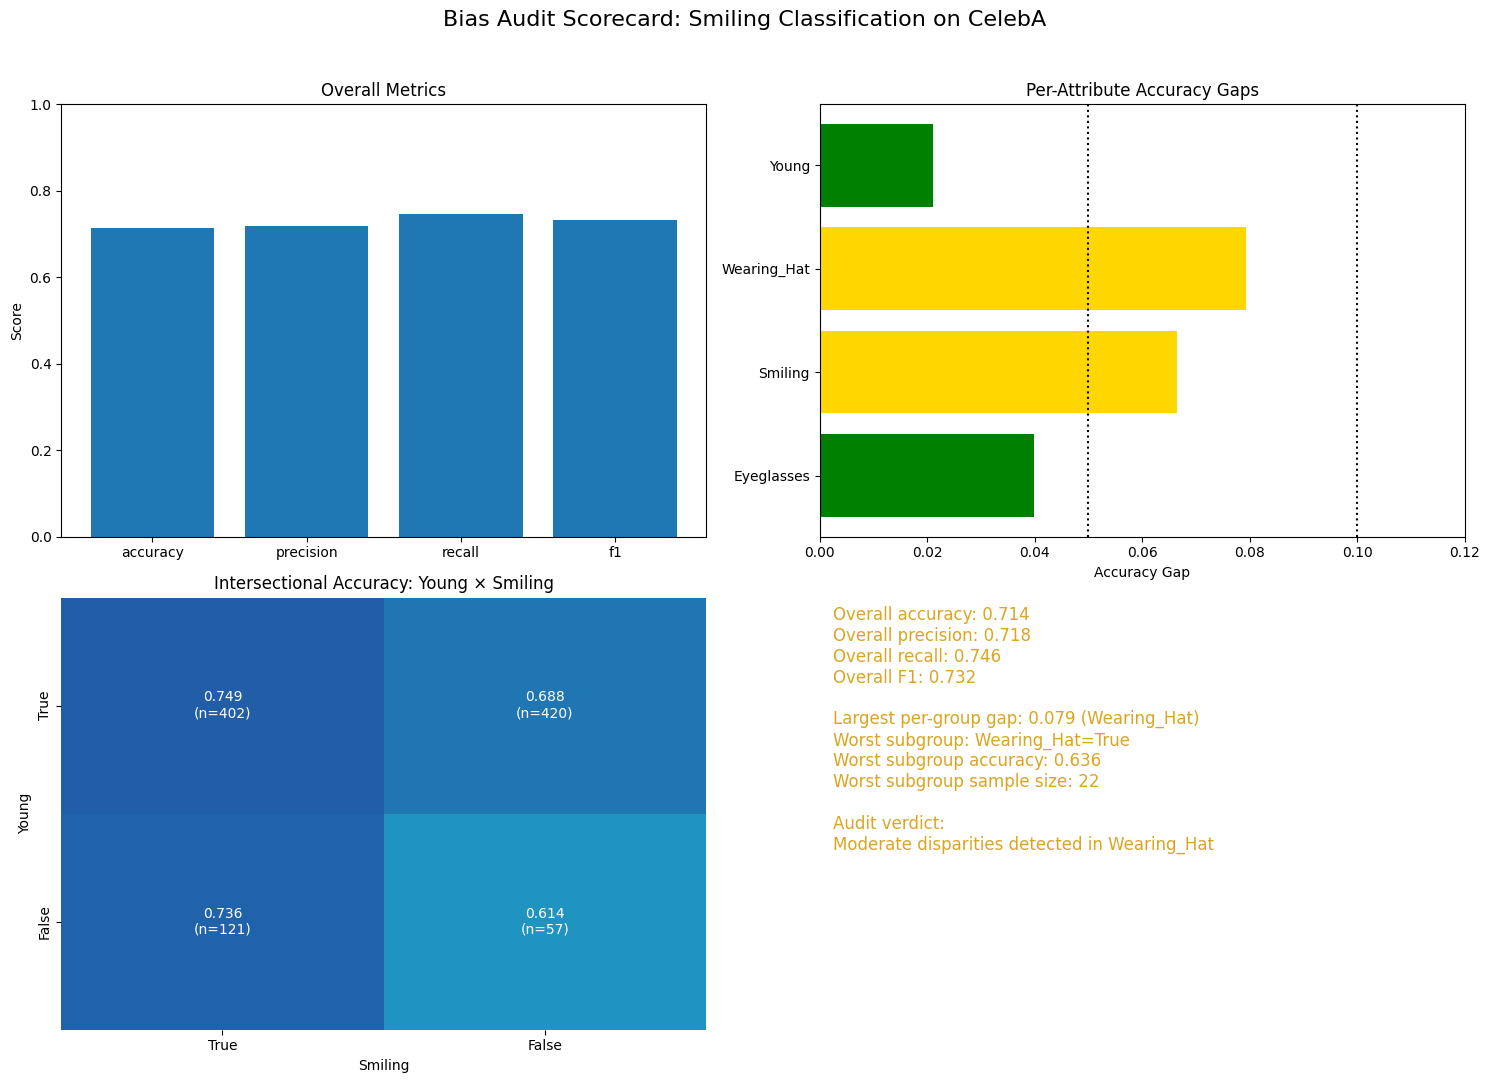

In [7]:
# Cell 7: Bias Scorecard

# Compute per-attribute accuracy gaps from subgroup results
gap_df = (
    group_metrics.groupby("attribute")["accuracy"]
    .agg(["max", "min"])
    .reset_index()
)
gap_df["gap"] = gap_df["max"] - gap_df["min"]

# Find largest subgroup gap and its attribute
largest_gap_row = gap_df.loc[gap_df["gap"].idxmax()]
largest_gap_attr = largest_gap_row["attribute"]
largest_gap_value = largest_gap_row["gap"]

# Recompute worst-performing subgroup for text panel
worst_group = group_metrics.loc[group_metrics["accuracy"].idxmin()]

# Decide audit verdict based on largest gap
if largest_gap_value < 0.05:
    verdict = "No significant disparities detected"
    verdict_color = "green"
elif largest_gap_value < 0.10:
    verdict = f"Moderate disparities detected in {largest_gap_attr}"
    verdict_color = "goldenrod"
else:
    verdict = f"Significant disparities detected in {largest_gap_attr}"
    verdict_color = "red"

# Create 2x2 audit scorecard figure
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle(f"Bias Audit Scorecard: {TARGET_ATTR} Classification on CelebA", fontsize=16)

# Panel 1: overall metrics bar chart
metric_names = list(overall_metrics.keys())
metric_values = list(overall_metrics.values())
axes[0, 0].bar(metric_names, metric_values)
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_title("Overall Metrics")
axes[0, 0].set_ylabel("Score")

# Panel 2: per-attribute accuracy gap chart
gap_colors = []
for g in gap_df["gap"]:
    if g < 0.05:
        gap_colors.append("green")
    elif g < 0.10:
        gap_colors.append("gold")
    else:
        gap_colors.append("red")

axes[0, 1].barh(gap_df["attribute"], gap_df["gap"], color=gap_colors)
axes[0, 1].axvline(0.05, linestyle=":", linewidth=1.5, color="black")
axes[0, 1].axvline(0.10, linestyle=":", linewidth=1.5, color="black")
axes[0, 1].set_xlim(0, max(0.12, gap_df["gap"].max() + 0.02))
axes[0, 1].set_title("Per-Attribute Accuracy Gaps")
axes[0, 1].set_xlabel("Accuracy Gap")

# Panel 3: intersectional heatmap from Cell 5
sns.heatmap(
    acc_matrix,
    annot=annot,
    fmt="",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar=False,
    ax=axes[1, 0],
)
axes[1, 0].set_title(f"Intersectional Accuracy: {ATTR_A} × {ATTR_B}")
axes[1, 0].set_xlabel(ATTR_B)
axes[1, 0].set_ylabel(ATTR_A)

# Panel 4: text summary panel
axes[1, 1].axis("off")
summary_text = (
    f"Overall accuracy: {overall_metrics['accuracy']:.3f}\n"
    f"Overall precision: {overall_metrics['precision']:.3f}\n"
    f"Overall recall: {overall_metrics['recall']:.3f}\n"
    f"Overall F1: {overall_metrics['f1']:.3f}\n\n"
    f"Largest per-group gap: {largest_gap_value:.3f} ({largest_gap_attr})\n"
    f"Worst subgroup: {worst_group['attribute']}={worst_group['group']}\n"
    f"Worst subgroup accuracy: {worst_group['accuracy']:.3f}\n"
    f"Worst subgroup sample size: {int(worst_group['n_samples'])}\n\n"
    f"Audit verdict:\n{verdict}"
)
axes[1, 1].text(
    0.02,
    0.98,
    summary_text,
    va="top",
    ha="left",
    fontsize=12,
    color=verdict_color,
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

###Cell 7 Output
summarizes audit results. The model had 71.4% overall accuracy, and the largest subgroup gap was for Wearing_Hat. The scorecard labels this as a moderate disparity because the Wearing_Hat=True subgroup had the lowest accuracy at 63.6%.

### Cell 8:
Displays misclassified images from the lowest-performing subgroups to look for visible error patterns.

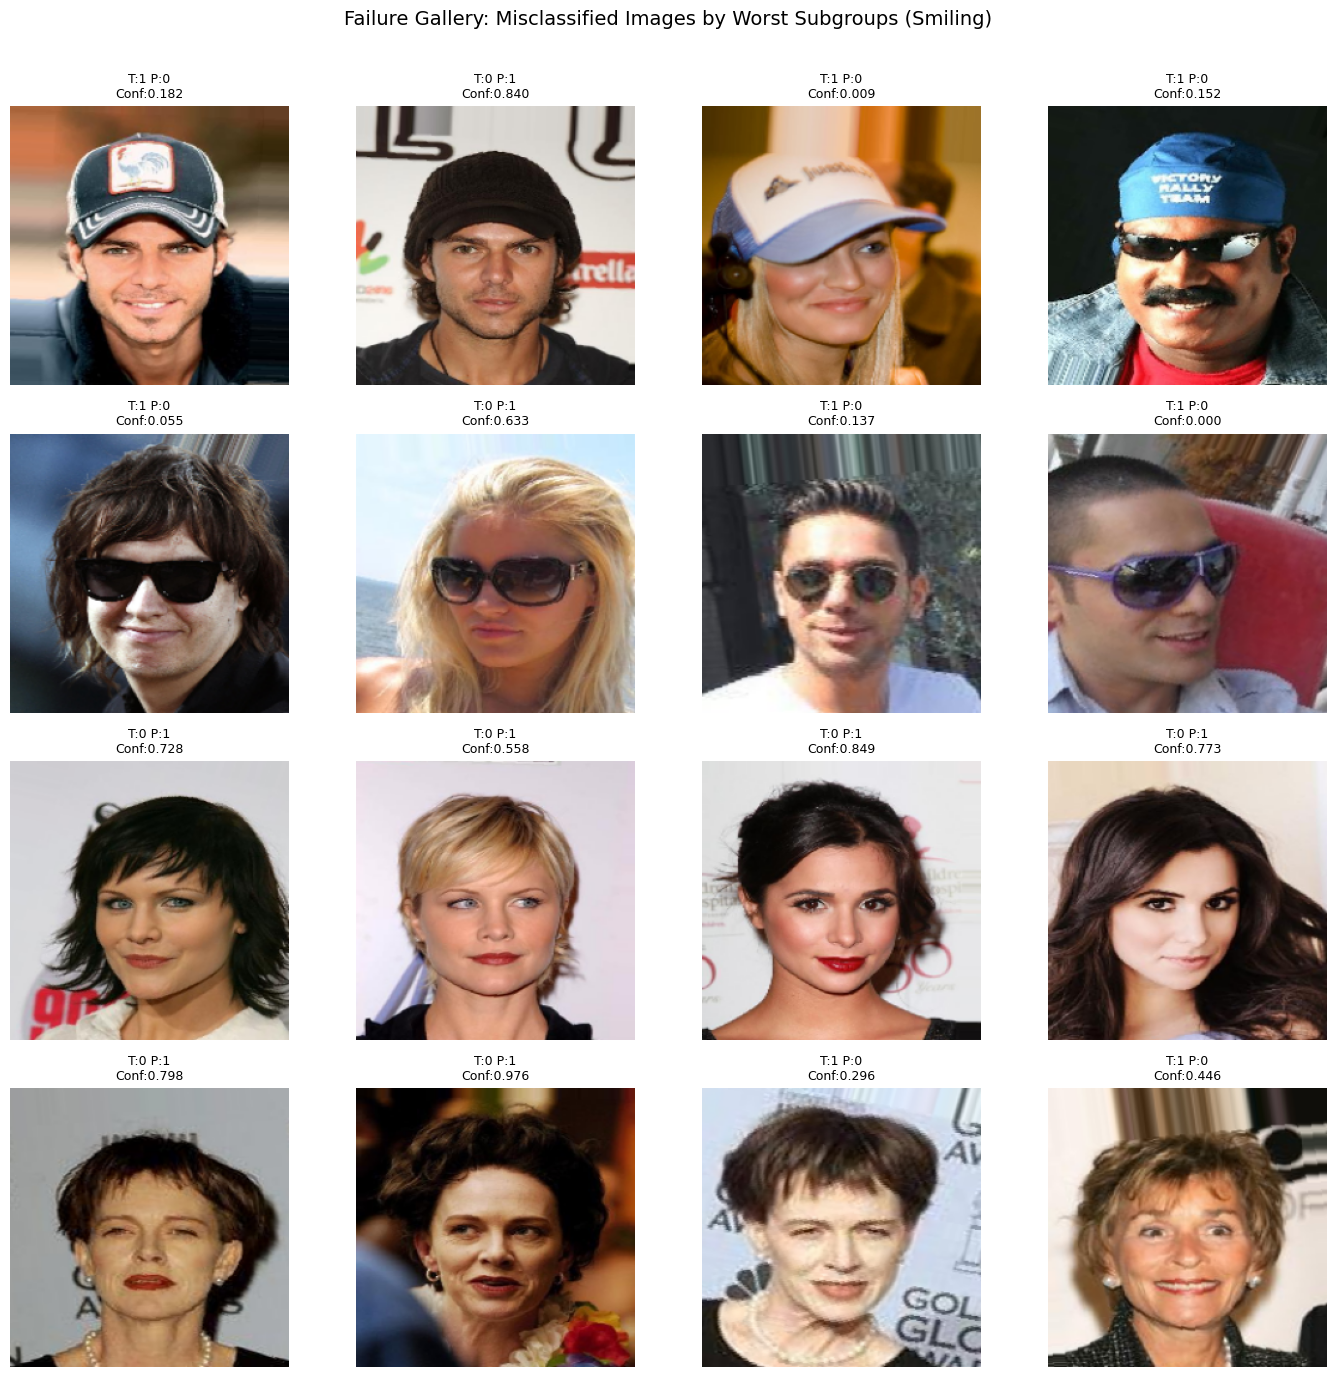

In [8]:
# Cell 8: Failure Gallery

# Sort groups from worst to best by accuracy
worst_groups = group_metrics.sort_values(["accuracy", "n_samples"], ascending=[True, False]).head(4)

# Create 4x4 gallery layout for subgroup failures
fig, axes = plt.subplots(4, 4, figsize=(14, 14))

for row_idx, (_, row) in enumerate(worst_groups.iterrows()):
    # Build subgroup mask for current row
    subgroup_mask = labels_df[row["attribute"]] == row["group"]

    # Find misclassified examples inside this subgroup
    mis_idx = np.where(subgroup_mask & (y_true != y_pred))[0]

    # Label the row using the first subplot
    row_label = f"{row['attribute']}={row['group']}\nAcc={row['accuracy']:.3f}, n={int(row['n_samples'])}"
    axes[row_idx, 0].set_ylabel(row_label, rotation=0, labelpad=60, va="center", fontsize=10)

    # If no errors exist, show a text message and blank the row
    if len(mis_idx) == 0:
        for col_idx in range(4):
            axes[row_idx, col_idx].axis("off")
        axes[row_idx, 1].text(0.5, 0.5, "No errors in this subgroup", ha="center", va="center", fontsize=10)
        continue

    # Show up to four misclassified images for this subgroup
    shown_idx = mis_idx[:4]
    for col_idx in range(4):
        ax = axes[row_idx, col_idx]
        ax.axis("off")

        # Leave blank cells if fewer than four errors exist
        if col_idx >= len(shown_idx):
            continue

        idx = shown_idx[col_idx]

        # Display raw image as uint8 for plotting
        ax.imshow(test_images_raw[idx].astype("uint8"))

        # Add true label, predicted label, and confidence to title
        ax.set_title(
            f"T:{int(y_true[idx])} P:{int(y_pred[idx])}\nConf:{y_pred_proba[idx]:.3f}",
            fontsize=9,
        )

plt.suptitle(f"Failure Gallery: Misclassified Images by Worst Subgroups ({TARGET_ATTR})", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

###Cell 8 Output
shows misclassified images from the weakest subgroups. The errors seem to happen most when a smile with teeth is not obvious or fully visible, especially when teeth are hidden, the mouth is partly covered by facial hair, the face is angled

### Cell 9
Tests different prediction thresholds to see how accuracy and subgroup gaps change.

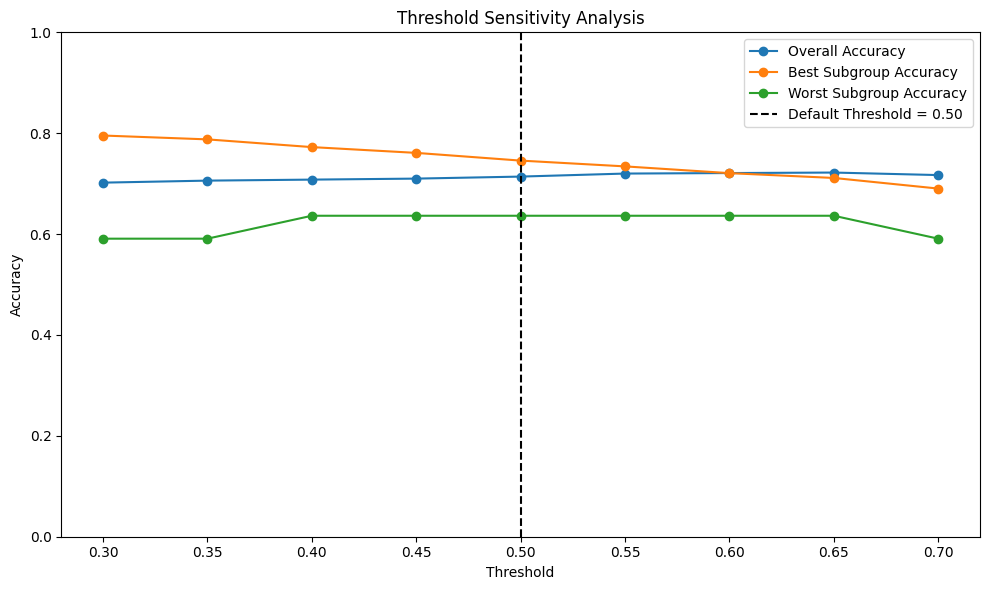

Threshold minimizing subgroup gap: 0.65
Gap at that threshold: 0.075
Gap at 0.50: 0.109
Overall accuracy at 0.65: 0.722
Overall accuracy at 0.50: 0.714


In [9]:
# Cell 9: Threshold Sweep

# Create thresholds from 0.30 to 0.70 in steps of 0.05
thresholds = np.arange(0.30, 0.71, 0.05)

# Identify best and worst subgroup names from Cell 4
best_group = group_metrics.loc[group_metrics["accuracy"].idxmax()]
worst_group = group_metrics.loc[group_metrics["accuracy"].idxmin()]

# Build masks for the fixed best and worst subgroups
best_mask = labels_df[best_group["attribute"]] == best_group["group"]
worst_mask = labels_df[worst_group["attribute"]] == worst_group["group"]

# Store threshold sweep results
overall_accs = []
best_accs = []
worst_accs = []
gap_results = []

for thr in thresholds:
    # Threshold probabilities at the current value
    y_thr = (y_pred_proba >= thr).astype(int)

    # Compute overall and subgroup accuracies
    overall_acc = accuracy_score(y_true, y_thr)
    best_acc = accuracy_score(y_true[best_mask], y_thr[best_mask])
    worst_acc = accuracy_score(y_true[worst_mask], y_thr[worst_mask])

    # Save threshold results
    overall_accs.append(overall_acc)
    best_accs.append(best_acc)
    worst_accs.append(worst_acc)
    gap_results.append(abs(best_acc - worst_acc))

# Convert lists to arrays for easier indexing
overall_accs = np.array(overall_accs)
best_accs = np.array(best_accs)
worst_accs = np.array(worst_accs)
gap_results = np.array(gap_results)

# Find threshold with the smallest subgroup gap
best_gap_idx = np.argmin(gap_results)
best_threshold = thresholds[best_gap_idx]
best_gap = gap_results[best_gap_idx]

# Find the default threshold index for comparison
default_idx = np.where(np.isclose(thresholds, 0.50))[0][0]
default_gap = gap_results[default_idx]
default_overall_acc = overall_accs[default_idx]
best_threshold_overall_acc = overall_accs[best_gap_idx]

# Plot threshold sensitivity lines
plt.figure(figsize=(10, 6))
plt.plot(thresholds, overall_accs, marker="o", label="Overall Accuracy")
plt.plot(thresholds, best_accs, marker="o", label="Best Subgroup Accuracy")
plt.plot(thresholds, worst_accs, marker="o", label="Worst Subgroup Accuracy")
plt.axvline(0.50, linestyle="--", linewidth=1.5, color="black", label="Default Threshold = 0.50")
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Threshold Sensitivity Analysis")
plt.legend()
plt.tight_layout()
plt.show()

# Print threshold fairness comparison
print(f"Threshold minimizing subgroup gap: {best_threshold:.2f}")
print(f"Gap at that threshold: {best_gap:.3f}")
print(f"Gap at 0.50: {default_gap:.3f}")
print(f"Overall accuracy at {best_threshold:.2f}: {best_threshold_overall_acc:.3f}")
print(f"Overall accuracy at 0.50: {default_overall_acc:.3f}")

Cell 9 shows that raising the threshold to 0.65, making the model more strict about calling something a smile, reduced the performance gap between subgroups from 0.109 to 0.075. Overall accuracy also improved slightly from 71.4% to 72.2% with the stricter setting.